# Chapter 15 — The scaling wall

*Companion notebook to **The Learned Kernel**, Ch. 15. Run top to bottom.*

A fitted kernel machine (Ch. 8) trains cheaply on a small support subset, but a prediction is the
kernel-ridge solve $\alpha=(K+\lambda I)^{-1}y$ over the **full** train set of $n$ rows. Two costs
grow with $n$ and they are **different walls**: forming the dense Gram $K\in\mathbb{R}^{n\times n}$ is
$O(n^2)$ **memory**, factoring $K+\lambda I$ is $O(n^3)$ **flops**. This notebook watches both walls
arrive on real data, shows the ridge $\lambda$ doing double duty as regularizer and conditioner, and
lays out the three doors through the wall (Ch. 16–18).

## Setup (GPU strongly recommended)

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch15

set_style()

## 15.1  Two walls, in memory and in flops

The dense decode forms $K$ ($O(n^2)$ memory, $O(n^2 d_\phi)$ flops), factors $K+\lambda I$
($O(n^3)$), then solves two triangular systems ($O(n^2)$). In float64 the Gram alone occupies
$8n^2/10^9$ GB — 16 GB near $n=45{,}000$, 20 GB at $n=50{,}000$, before any factorization scratch.

In [3]:
for n in (10_000, 25_000, 45_000, 50_000, 100_000):
    print(f"n={n:>7,}  float64 Gram = {ch15.dense_gram_gb(n):6.1f} GB")

n= 10,000  float64 Gram =    0.8 GB
n= 25,000  float64 Gram =    5.0 GB
n= 45,000  float64 Gram =   16.2 GB
n= 50,000  float64 Gram =   20.0 GB
n=100,000  float64 Gram =   80.0 GB


## 15.2  Where the wall bites

California Housing (Ch. 8), tiled with small jitter to synthesize large $n$, decoded by a **fixed**
multi-scale Laplace kernel on one GPU. Peak memory tracks the $O(n^2)$ Gram; solve time tracks
$O(n^3)$. The accuracy is flat at $R^2\approx0.78$ — the wall is a wall of computation, not of fit.

In [4]:
timing = ch15.time_dense((2000, 4000, 8000, 16000))
print(f"{'n':>7} {'solve_s':>9} {'peak_GB':>9} {'gram_GB':>9} {'test_R2':>9}")
for r in timing:
    print(f"{r['n']:>7} {r['solve_s']:>9.2f} {r['peak_gb']:>9.2f} "
          f"{r['gram_gb_f64']:>9.3f} {r['r2']:>9.3f}")

      n   solve_s   peak_GB   gram_GB   test_R2
   2000      0.22      0.37     0.032     0.731
   4000      0.11      0.80     0.128     0.748
   8000      0.60      2.57     0.512     0.769
  16000      3.96     10.26     2.048     0.781


The measured GB10 reference carries the curve to the out-of-memory cliff: the dense solve is skipped
at $n=50{,}000$ (≈64 GB peak) rather than run to failure.

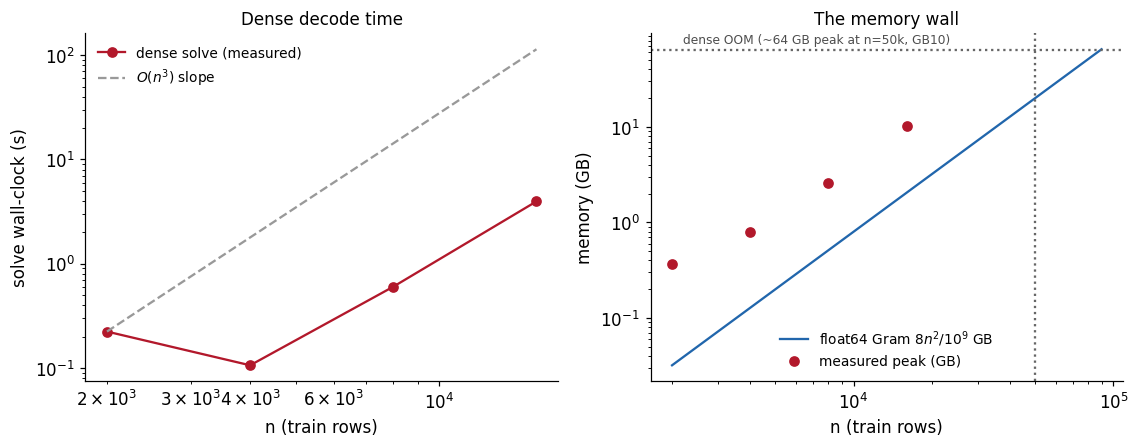

In [5]:
ch15.make_wall_figure(timing);

## 15.3  The ridge conditions the system

The ridge $\lambda$ is the regularizer of Ch. 2 **and** the noise variance of Ch. 5 **and** what
makes the system solvable quickly. Because $K\succeq0$, every eigenvalue of $K+\lambda I$ is at least
$\lambda$, so $\kappa(K+\lambda I)\le(\lambda_{\max}(K)+\lambda)/\lambda$. Iterative solvers converge
at a rate set by $\sqrt{\kappa}$ (Ch. 16), so a larger ridge speeds the solve.

In [6]:
print(f"{'lam':>8} {'kappa':>12} {'bound':>14} {'sqrt_kappa':>11}")
for r in ch15.conditioning_sweep(n=1500):
    print(f"{r['lam']:>8.0e} {r['kappa']:>12.1f} {r['bound']:>14.2e} {r['sqrt_kappa']:>11.1f}")

     lam        kappa          bound  sqrt_kappa


   1e-06       7322.3       4.41e+08        85.6
   1e-04       7310.2       4.41e+06        85.5
   1e-02       6280.6       4.41e+04        79.3
   1e-01       2754.4       4.41e+03        52.5
   1e+00        417.2       4.42e+02        20.4


### Interactive: the ridge as a conditioner

Drag $\log_{10}\lambda$ and watch the condition number and the iteration proxy $\sqrt{\kappa}$ fall
as the ridge grows. Larger $\lambda$: fewer Krylov iterations (Ch. 16), a smoother fit.

In [7]:
try:
    from ipywidgets import interact, FloatSlider
    import torch

    Xtr, _, _, _, _, _ = ch15.load_california_scaled()
    ker = ch15.MultiScaleKernel()
    K = ker.gram(Xtr[:1200], Xtr[:1200])

    def show(log_lam=-1.0):
        c = ch15.condition_number(K, 10.0 ** log_lam)
        print(f"lambda = {10.0**log_lam:.2e}")
        print(f"  condition number kappa = {c['kappa']:.1f}")
        print(f"  upper bound            = {c['bound']:.2e}")
        print(f"  iteration proxy sqrt(kappa) = {c['sqrt_kappa']:.1f}")

    interact(show, log_lam=FloatSlider(min=-6, max=1, step=0.5, value=-1,
                                       description="log10 lambda"))
except Exception as e:
    print("widget unavailable:", e)

interactive(children=(FloatSlider(value=-1.0, description='log10 lambda', max=1.0, min=-6.0, step=0.5), Output…

## 15.4  Three doors, one axis

The same trained kernel is decoded three ways: **matrix-free Krylov** (exact, removes the memory
wall, Ch. 16), **Nyström** (linear in $n$, removes both walls at an approximation floor, Ch. 17), and
**hardware** (Ch. 18). The `solver="auto"` ladder picks dense → matrix-free → Nyström as $n$ grows.

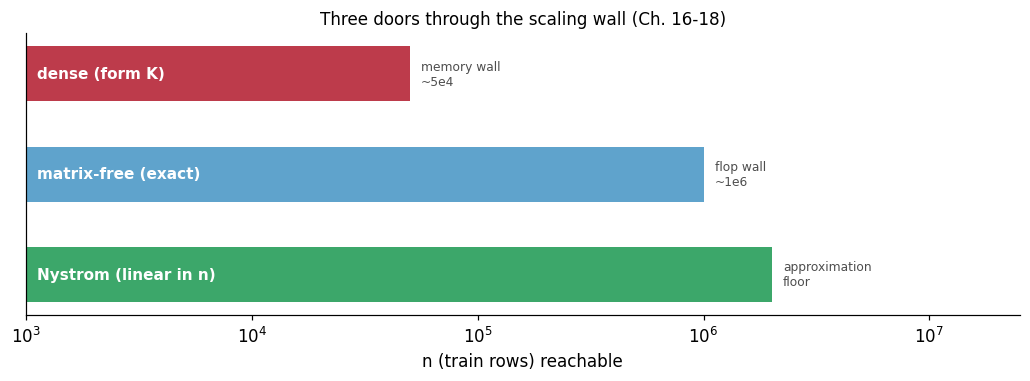

In [8]:
ch15.make_roadmap_figure();

## Exercises

**(easy)** Count the leading flops of dense KRR: forming $K$, the Cholesky factor of $K+\lambda I$,
and the triangular solves. Which term dominates as $n$ grows?

<details><summary>Solution</summary>

Form $K$: $O(n^2 d_\phi)$. Cholesky factor: $n^3/3$. Triangular solves: $O(n^2)$ per right-hand side.
The $n^3/3$ factorization dominates as $n$ grows; forming $K$ is the $O(n^2)$ **memory** wall, which
on a real device is reached first.
</details>

**(medium)** A device has 128 GB. Using the float64 storage law and a factor of three for scratch,
estimate the largest $n$ the dense solve reaches.

In [9]:
# TODO: solve 3 * 8 * n^2 / 1e9 = 128 for n.
budget_gb = 128.0
n_max = int((budget_gb * 1e9 / (3 * 8)) ** 0.5)
print("largest n ~", n_max)

largest n ~ 73029


<details><summary>Solution</summary>

$3\cdot 8 n^2/10^9 = 128 \Rightarrow n \approx 73{,}000$. The machine hits the **memory** wall first:
at that $n$ the $O(n^3)$ solve is still seconds-to-minutes, so storage, not compute, ends the job.
</details>

**(⋆)** Prove $\lambda$ lower-bounds the smallest eigenvalue of $K+\lambda I$ and bound $\kappa$.
State how the bound feeds the $O(\sqrt{\kappa})$ iteration count of Ch. 16.

<details><summary>Solution</summary>

$K\succeq0$ has eigenvalues in $[0,\lambda_{\max}(K)]$; adding $\lambda I$ shifts each to
$\lambda_i+\lambda\in[\lambda,\lambda_{\max}(K)+\lambda]$, so $\lambda_{\min}(K+\lambda I)\ge\lambda$
and $\kappa\le(\lambda_{\max}(K)+\lambda)/\lambda$. Conjugate gradients reach tolerance in
$O(\sqrt{\kappa}\log(1/\varepsilon))$ steps, so a larger $\lambda$ caps the iteration count.
</details>